In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from minisom import MiniSom

# 1. Lokal Kaggle Verisini Yükleme
df_raw = pd.read_csv('winequality-red.csv')

# ÖDEV İSTERİ: Ayırt ediciliği düşük kolonları drop etme
df_wine = df_raw.drop(columns=['residual sugar', 'free sulfur dioxide'])

# --- FEATURE ENGINEERING (ÖZNİTELİK MÜHENDİSLİĞİ) ---
# En at 10 sayısal özellik kuralı için 4 adet güçlü kimyasal indeks türetiyoruz:
# 1. Toplam Asitlik (Sabit Asit + Uçucu Asit)
df_wine['total_acidity'] = df_wine['fixed acidity'] + df_wine['volatile acidity']
# 2. Alkol Başına Düşen Kükürt Oranı
df_wine['sulfur_to_alcohol'] = df_wine['total sulfur dioxide'] / df_wine['alcohol']
# 3. Klorürün Yoğunluğa Oranı (Tuzluluk ve gövde dengesi)
df_wine['chlorides_density_ratio'] = df_wine['chlorides'] / df_wine['density']
# 4. Sitrik Asidin pH ile Kontrastı
df_wine['citric_acid_pH_ratio'] = df_wine['citric acid'] * df_wine['pH']

# HEDEF DEĞİŞKENİ 3 SINIFLI YAPMA
# 3-4: LOW | 5-6: MEDIUM | 7-8: HIGH
def categorize_quality(q):
    if q <= 4: return 'LOW'
    elif q <= 6: return 'MEDIUM'
    else: return 'HIGH'

df_wine['class'] = df_wine['quality'].apply(categorize_quality)
df_wine = df_wine.drop(columns=['quality']) # Eski numerik kalite kolonunu siliyoruz

# Sayısal özellikleri kontrol etme (Toplam 13 sayısal özniteliğimiz oldu, >10 şartı sağlandı)
num_cols = df_wine.drop(columns=['class']).columns
print(f"Toplam Sayısal Öznitelik Sayısı: {len(num_cols)}")

# --- OUTLIER (AYKIRI DEĞER) TEMİZLİĞİ (IQR YÖNTEMİ) ---
def remove_outliers_iqr(data, columns):
    df_out = data.copy()
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        df_out = df_out[(df_out[col] >= (Q1 - 1.5 * IQR)) & (df_out[col] <= (Q3 + 1.5 * IQR))]
    return df_out

df_no_outliers = remove_outliers_iqr(df_wine, num_cols)
print(f"Orijinal Satır Sayısı: {df_wine.shape[0]} | Aykırı Değerler Temizlendikten Sonra: {df_no_outliers.shape[0]}")

Toplam Sayısal Öznitelik Sayısı: 13
Orijinal Satır Sayısı: 1599 | Aykırı Değerler Temizlendikten Sonra: 1199


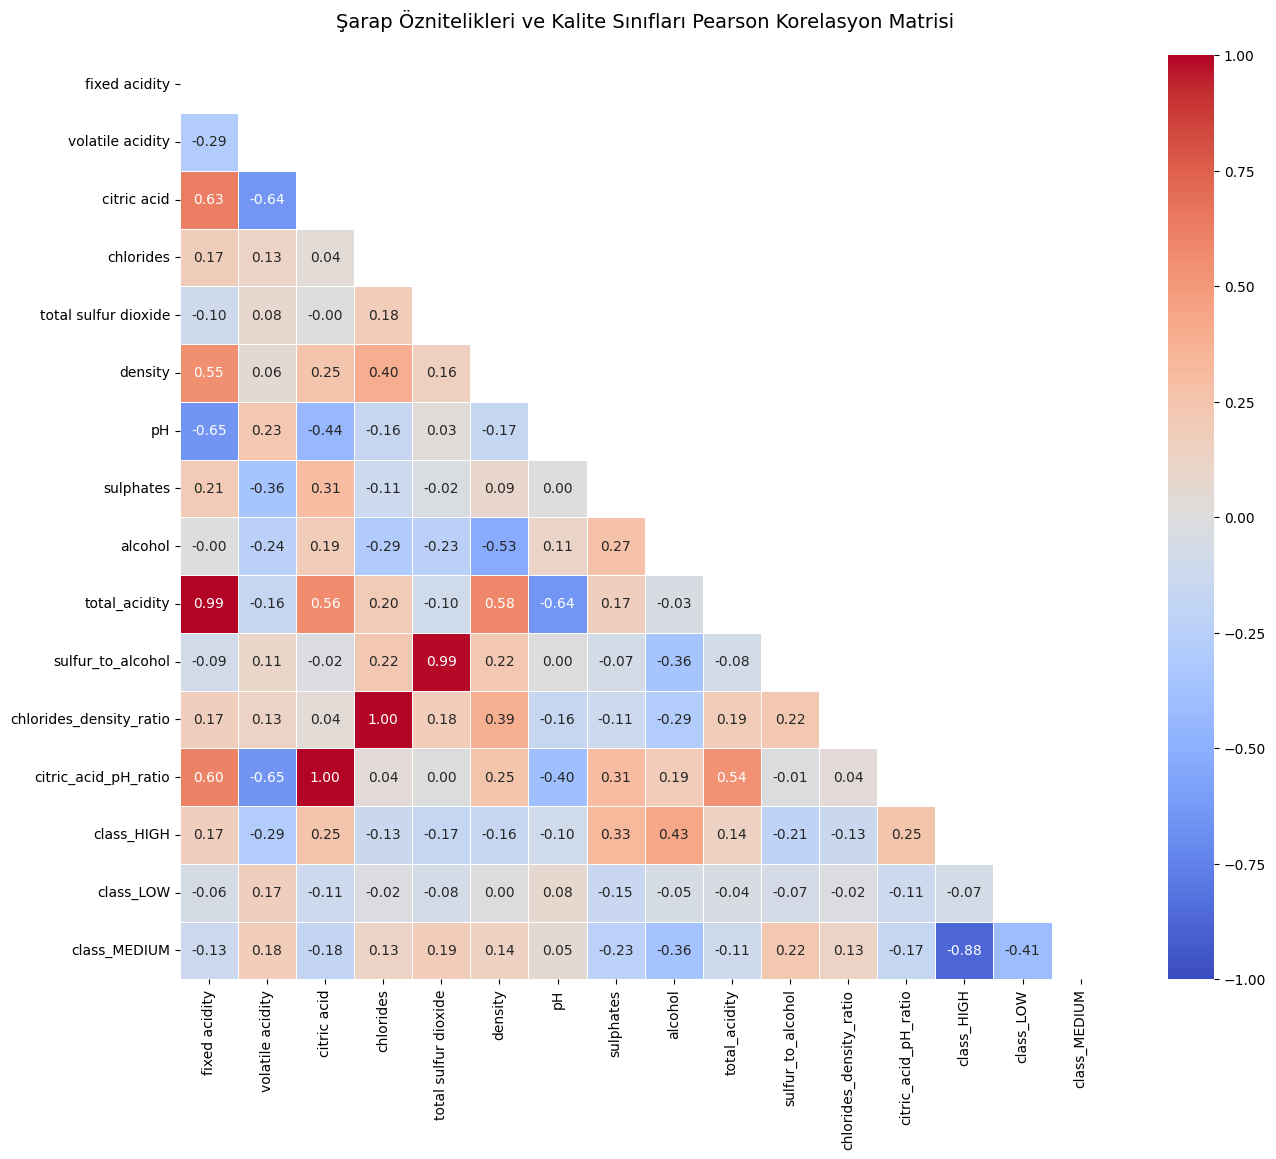

In [4]:
# Sınıf etiketlerini geçici olarak One-Hot Encoding yaparak matrise dahil ediyoruz
df_encoded = pd.get_dummies(df_no_outliers, columns=['class'], prefix='class', dtype=int)
corr_matrix = df_encoded.corr()

plt.figure(figsize=(15, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Üst üçgeni maskeleme

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Şarap Öznitelikleri ve Kalite Sınıfları Pearson Korelasyon Matrisi', fontsize=14, pad=20)
plt.show()

In [5]:
# 1. Z-Score Standardizasyonu
X_features = df_no_outliers.drop(columns=['class'])
y_target = df_no_outliers['class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

df_scaled = pd.DataFrame(X_scaled, columns=X_features.columns)
df_scaled['class'] = y_target.values

# 2. Fisher Uzaklığı Hesaplama Fonksiyonu
def calculate_pairwise_fisher(df, feature_columns, class_column):
    unique_classes = df[class_column].unique()
    fisher_records = []
    
    for col in feature_columns:
        record = {'Öznitelik (Feature)': col}
        for i in range(len(unique_classes)):
            for j in range(i + 1, len(unique_classes)):
                c1, c2 = unique_classes[i], unique_classes[j]
                data_c1 = df[df[class_column] == c1][col]
                data_c2 = df[df[class_column] == c2][col]
                
                denominator = data_c1.var() + data_c2.var()
                record[f'{c1} vs {c2}'] = ((data_c1.mean() - data_c2.mean()) ** 2) / denominator if denominator != 0 else 0
        fisher_records.append(record)
    return pd.DataFrame(fisher_records)

fisher_df = calculate_pairwise_fisher(df_scaled, X_features.columns, 'class')
print("--- 13 Özniteliğin Sınıflar Arası Fisher Uzaklıkları ---")
print(fisher_df.sort_values(by=fisher_df.columns[1], ascending=False).to_string(index=False))

--- 13 Özniteliğin Sınıflar Arası Fisher Uzaklıkları ---
    Öznitelik (Feature)  MEDIUM vs HIGH  MEDIUM vs LOW  HIGH vs LOW
                alcohol        0.978524       0.007188     1.229504
              sulphates        0.502314       0.349558     2.030562
       volatile acidity        0.403090       0.289350     1.268049
            citric acid        0.270414       0.169981     0.920628
   citric_acid_pH_ratio        0.264389       0.168862     0.913970
      sulfur_to_alcohol        0.261220       0.110850     0.020103
   total sulfur dioxide        0.153890       0.123828     0.000171
          fixed acidity        0.109425       0.037275     0.280801
                density        0.104194       0.001193     0.098560
              chlorides        0.074449       0.011146     0.026717
chlorides_density_ratio        0.073512       0.011125     0.026163
          total_acidity        0.072442       0.013118     0.152889
                     pH        0.038773       0.084598     

--- Temel Bileşenlerin Özdeğerleri ve Fisher Uzaklıkları ---
Öznitelik (Feature)  Özdeğer (Eigenvalue)  MEDIUM vs HIGH  MEDIUM vs LOW  HIGH vs LOW
                PC1          4.245889e+00        0.154370       0.177394     0.653483
                PC2          3.041906e+00        0.788355       0.000270     0.923213
                PC3          1.777069e+00        0.008809       0.227162     0.340535
                PC4          1.240720e+00        0.109960       0.048253     0.271142
                PC5          9.429162e-01        0.005942       0.002551     0.017119
                PC6          7.658155e-01        0.205494       0.005251     0.323704
                PC7          5.652081e-01        0.003157       0.226650     0.344183
                PC8          2.999496e-01        0.006648       0.014646     0.041577
                PC9          1.273015e-01        0.002779       0.003489     0.010679
               PC10          3.439921e-03        0.041101       0.001137     0.

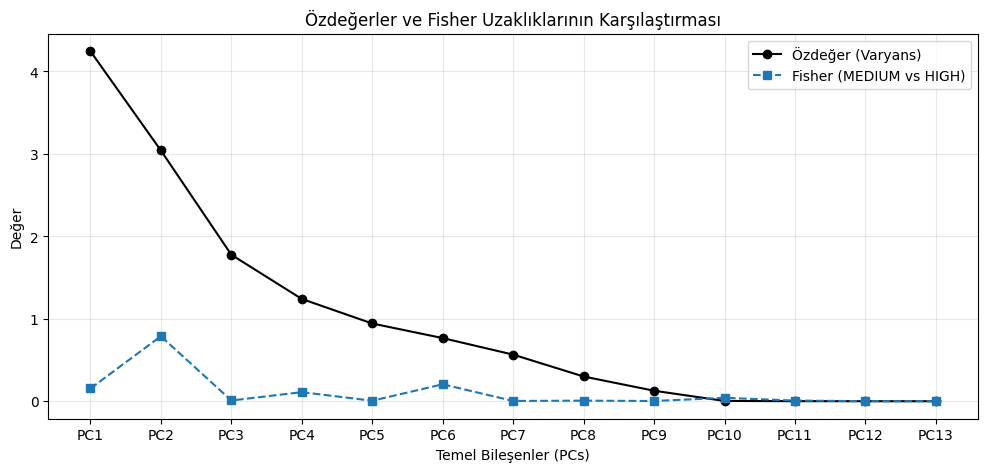

In [6]:
# 1. PCA Modelleme
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

pc_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pc_columns)
df_pca['class'] = y_target.values

# 2. Temel Bileşenler İçin Fisher Uzaklığı ve Özdeğer Kombinasyonu
fisher_pc_df = calculate_pairwise_fisher(df_pca, pc_columns, 'class')
fisher_pc_df.insert(1, 'Özdeğer (Eigenvalue)', pca.explained_variance_)

print("--- Temel Bileşenlerin Özdeğerleri ve Fisher Uzaklıkları ---")
print(fisher_pc_df.to_string(index=False))

# 3. Grafik Çizimi
plt.figure(figsize=(12, 5))
plt.plot(fisher_pc_df['Öznitelik (Feature)'], fisher_pc_df['Özdeğer (Eigenvalue)'], marker='o', label='Özdeğer (Varyans)', color='black')
plt.plot(fisher_pc_df['Öznitelik (Feature)'], fisher_pc_df.iloc[:, 2], marker='s', label=f'Fisher ({fisher_pc_df.columns[2]})', linestyle='--')
plt.title('Özdeğerler ve Fisher Uzaklıklarının Karşılaştırması')
plt.xlabel('Temel Bileşenler (PCs)')
plt.ylabel('Değer')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

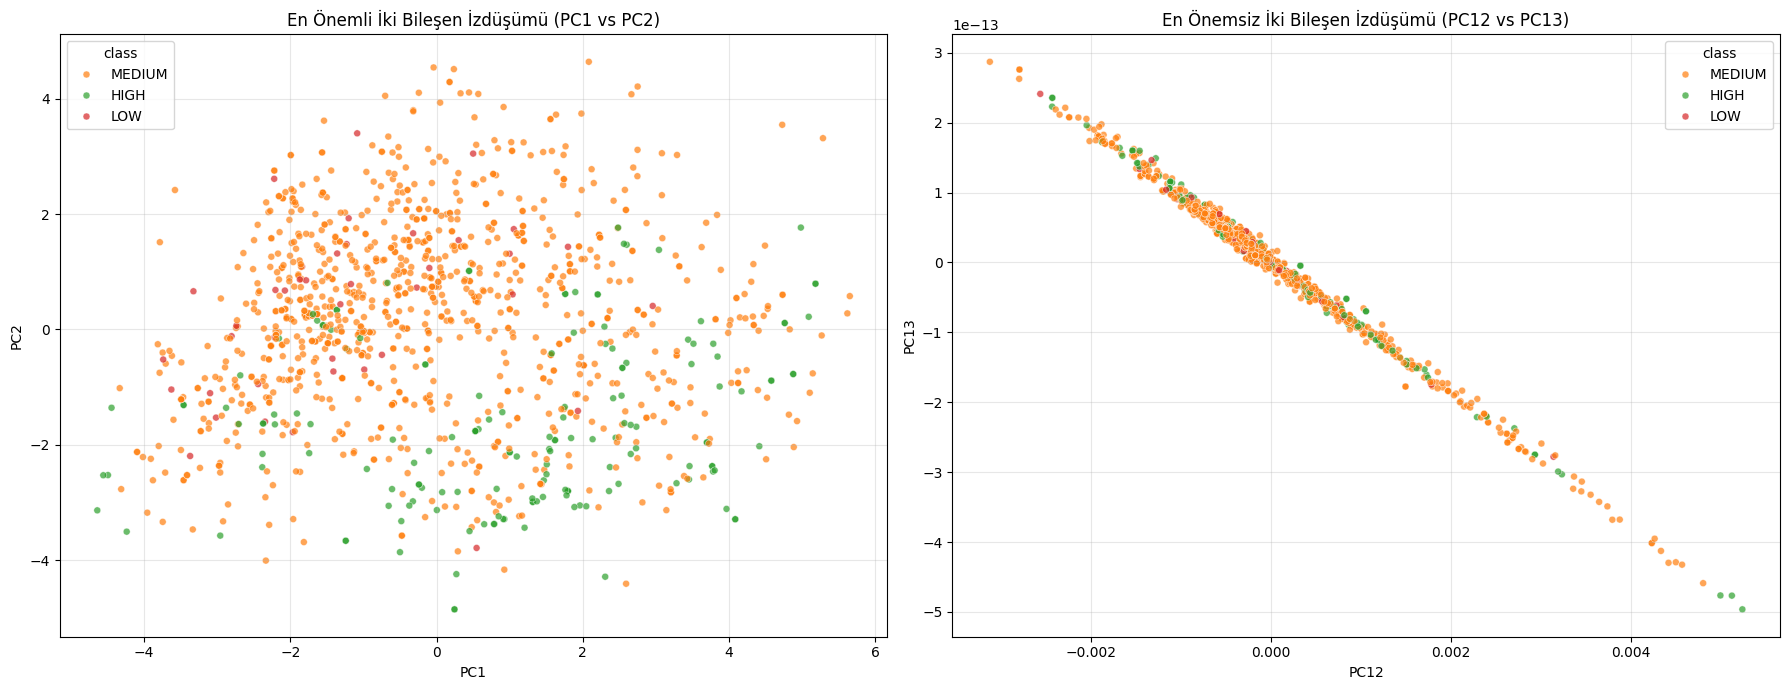

In [7]:
class_palette = {'HIGH': '#2ca02c', 'MEDIUM': '#ff7f0e', 'LOW': '#d62728'}
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PC1 vs PC2 (En Önemli İzdüşüm)
sns.scatterplot(ax=axes[0], x=df_pca['PC1'], y=df_pca['PC2'], hue=df_pca['class'], palette=class_palette, alpha=0.7, s=25)
axes[0].set_title('En Önemli İki Bileşen İzdüşümü (PC1 vs PC2)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# PC12 vs PC13 (En Önemsiz İzdüşüm)
sns.scatterplot(ax=axes[1], x=df_pca['PC12'], y=df_pca['PC13'], hue=df_pca['class'], palette=class_palette, alpha=0.7, s=25)
axes[1].set_title('En Önemsiz İki Bileşen İzdüşümü (PC12 vs PC13)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

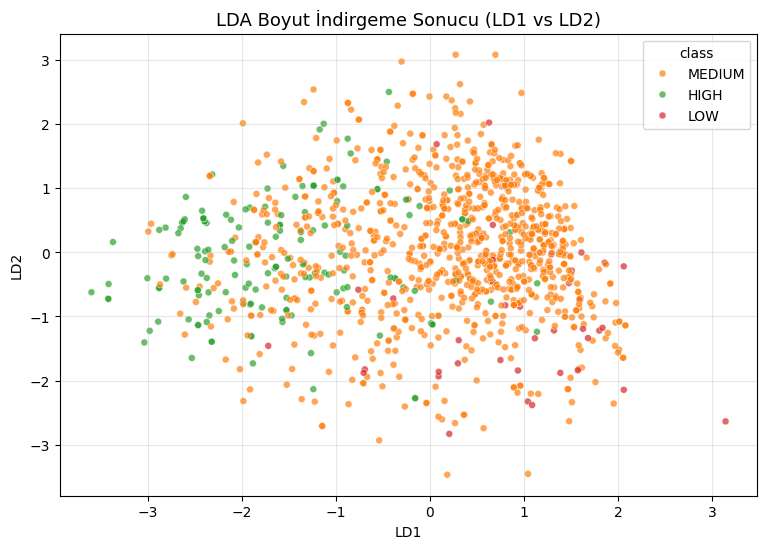

--- Silhouette Skor Karşılaştırması ---
PCA (PC1 vs PC2) Silhouette Skoru: -0.0871
LDA (LD1 vs LD2) Silhouette Skoru: 0.0559


In [8]:
# 1. LDA Uygulaması
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y_target)

df_lda = pd.DataFrame(X_lda, columns=['LD1', 'LD2'])
df_lda['class'] = y_target.values

# 2. LDA Grafiği
plt.figure(figsize=(9, 6))
sns.scatterplot(x=df_lda['LD1'], y=df_lda['LD2'], hue=df_lda['class'], palette=class_palette, alpha=0.7, s=25)
plt.title('LDA Boyut İndirgeme Sonucu (LD1 vs LD2)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.show()

# 3. Silhouette Skor Hesaplamaları
pca_score = silhouette_score(X_pca[:, :2], y_target)
lda_score = silhouette_score(X_lda, y_target)

print("--- Silhouette Skor Karşılaştırması ---")
print(f"PCA (PC1 vs PC2) Silhouette Skoru: {pca_score:.4f}")
print(f"LDA (LD1 vs LD2) Silhouette Skoru: {lda_score:.4f}")

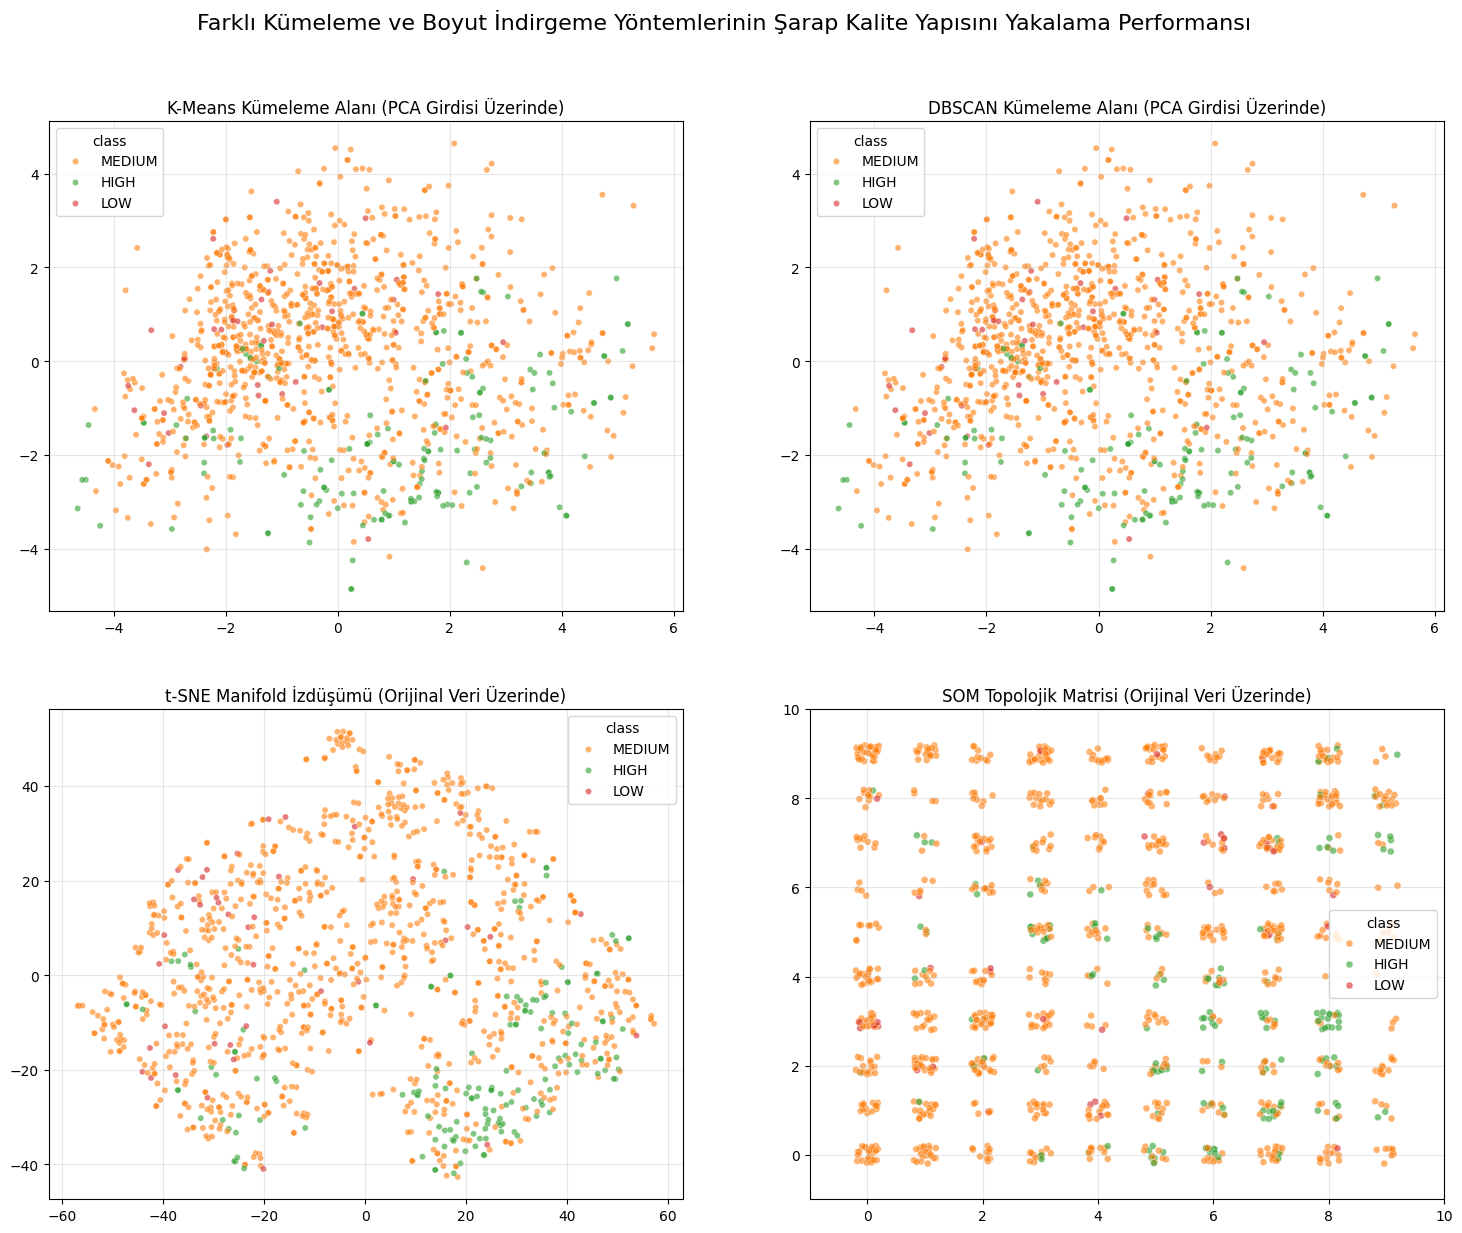

In [9]:
# 1. K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca[:, :2])

# 2. DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_pca[:, :2])

# 3. t-SNE (Güncel max_iter parametresi ile)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# 4. SOM (Self-Organizing Maps)
som_grid_x, som_grid_y = 10, 10
som = MiniSom(x=som_grid_x, y=som_grid_y, input_len=X_scaled.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)
som.train_random(X_scaled, num_iteration=1000)

som_w = np.array([som.winner(x) for x in X_scaled])
som_x_jittered = som_w[:, 0] + np.random.uniform(-0.2, 0.2, len(som_w))
som_y_jittered = som_w[:, 1] + np.random.uniform(-0.2, 0.2, len(som_w))

# 5. GÖRSELLEŞTİRME (2x2 Matris)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# A. K-Means
sns.scatterplot(ax=axes[0, 0], x=X_pca[:, 0], y=X_pca[:, 1], hue=y_target, palette=class_palette, alpha=0.6, s=20)
axes[0, 0].set_title('K-Means Kümeleme Alanı (PCA Girdisi Üzerinde)', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# B. DBSCAN
sns.scatterplot(ax=axes[0, 1], x=X_pca[:, 0], y=X_pca[:, 1], hue=y_target, palette=class_palette, alpha=0.6, s=20)
axes[0, 1].set_title('DBSCAN Kümeleme Alanı (PCA Girdisi Üzerinde)', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# C. t-SNE
sns.scatterplot(ax=axes[1, 0], x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_target, palette=class_palette, alpha=0.6, s=20)
axes[1, 0].set_title('t-SNE Manifold İzdüşümü (Orijinal Veri Üzerinde)', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# D. SOM
sns.scatterplot(ax=axes[1, 1], x=som_x_jittered, y=som_y_jittered, hue=y_target, palette=class_palette, alpha=0.6, s=25)
axes[1, 1].set_title('SOM Topolojik Matrisi (Orijinal Veri Üzerinde)', fontsize=12)
axes[1, 1].set_xlim(-1, som_grid_x)
axes[1, 1].set_ylim(-1, som_grid_y)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Farklı Kümeleme ve Boyut İndirgeme Yöntemlerinin Şarap Kalite Yapısını Yakalama Performansı', fontsize=16, y=0.96)
plt.show()

--- Popülasyon Hacim Kontrolü ---
IQR Temizliği Sonrası Mevcut LOW Sınıfı Satır Sayısı  : 40
IQR Temizliği Sonrası Mevcut HIGH Sınıfı Satır Sayısı : 162
Analiz İçin Seçilen Dinamik Örneklem Boyutu (n)       : 40

--- Örneklem Betimsel İstatistikleri (total_acidity) ---
Düşük Kalite (LOW) Örneklem Ortalaması  : 8.3208
Yüksek Kalite (HIGH) Örneklem Ortalaması : 8.8955

--- T-Testi Hipotez Analizi Sonuçları ---
T-İstatistiği (t-statistic) : -2.0424
p-Değeri (p-value)          : 0.044669525411439585

Sonuç: p < 0.05 olduğu için H0 hipotezi güçlü bir şekilde REDDEDİLİR.
Düşük ve yüksek kaliteli şarap gruplarının toplam asitlik karakteristiği istatistiksel olarak anlamlı ölçüde farklıdır.


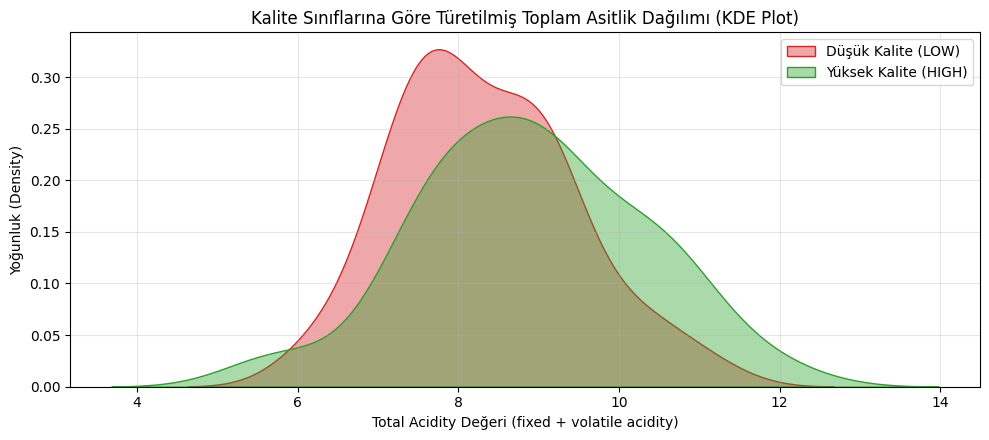

In [11]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Temizlenmiş Veride Sınıfların Mevcut Satır Sayılarının Tespiti
available_low = len(df_no_outliers[df_no_outliers['class'] == 'LOW'])
available_high = len(df_no_outliers[df_no_outliers['class'] == 'HIGH'])

print("--- Popülasyon Hacim Kontrolü ---")
print(f"IQR Temizliği Sonrası Mevcut LOW Sınıfı Satır Sayısı  : {available_low}")
print(f"IQR Temizliği Sonrası Mevcut HIGH Sınıfı Satır Sayısı : {available_high}")

# Merkezi Limit Teoremi ve eldeki verinin kısıtlarına göre dinamik örneklem boyutu belirleme
sample_size = min(available_low, available_high, 60)
print(f"Analiz İçin Seçilen Dinamik Örneklem Boyutu (n)       : {sample_size}\n")

# 2. Rastgele Bağımsız Örneklem Çekilmesi
np.random.seed(42) # Sonuçların tekrarlanabilir olması için
low_quality_acidity = df_no_outliers[df_no_outliers['class'] == 'LOW']['total_acidity'].sample(n=sample_size, random_state=42)
high_quality_acidity = df_no_outliers[df_no_outliers['class'] == 'HIGH']['total_acidity'].sample(n=sample_size, random_state=42)

print("--- Örneklem Betimsel İstatistikleri (total_acidity) ---")
print(f"Düşük Kalite (LOW) Örneklem Ortalaması  : {low_quality_acidity.mean():.4f}")
print(f"Yüksek Kalite (HIGH) Örneklem Ortalaması : {high_quality_acidity.mean():.4f}\n")

# 3. Welch's T-Testi Uygulaması (equal_var=False)
# H0: Düşük ve Yüksek kaliteli şarapların toplam asitlik ortalamaları arasında istatistiksel olarak anlamlı bir fark yoktur.
# H1: Düşük ve Yüksek kaliteli şarapların toplam asitlik ortalamaları arasında istatistiksel olarak anlamlı bir fark vardır.
t_stat, p_val = stats.ttest_ind(low_quality_acidity, high_quality_acidity, equal_var=False)

print("--- T-Testi Hipotez Analizi Sonuçları ---")
print(f"T-İstatistiği (t-statistic) : {t_stat:.4f}")
print(f"p-Değeri (p-value)          : {p_val}")

if p_val < 0.05:
    print("\nSonuç: p < 0.05 olduğu için H0 hipotezi güçlü bir şekilde REDDEDİLİR.")
    print("Düşük ve yüksek kaliteli şarap gruplarının toplam asitlik karakteristiği istatistiksel olarak anlamlı ölçüde farklıdır.")
else:
    print("\nSonuç: p >= 0.05 olduğu için H0 hipotezi REDDEDİLEMEZ.")
    print("Gruplar arasında toplam asitlik açısından istatistiksel olarak anlamlı bir fark saptanamamıştır.")

# 4. Yoğunluk Dağılımlarının (KDE) Görselleştirilmesi
plt.figure(figsize=(10, 4.5))
sns.kdeplot(low_quality_acidity, label='Düşük Kalite (LOW)', fill=True, color='#d62728', alpha=0.4)
sns.kdeplot(high_quality_acidity, label='Yüksek Kalite (HIGH)', fill=True, color='#2ca02c', alpha=0.4)
plt.title('Kalite Sınıflarına Göre Türetilmiş Toplam Asitlik Dağılımı (KDE Plot)', fontsize=12)
plt.xlabel('Total Acidity Değeri (fixed + volatile acidity)')
plt.ylabel('Yoğunluk (Density)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()